# DISORT + Monte Carlo two-level iteration

This notebook builds a simple coma with initial level ratios `rL0 = 1` and `rL1 = 0`, uses `solve_disort_layers` to compute `J_v_stream_average`, and then alternates:

1. `solve_disort_layers` to update the radiation field
2. `monte_carlo_two_level_populations` to update the level populations

The loop stops when every layer satisfies a relative `J_v` change smaller than `1e-3`.


In [12]:
import sys
sys.path.append('../')  # Adjust the path

In [13]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import Constants as constants
from ComaGrid import ComaGrid
from Einstein_coeff import einstein_coeffs_B
from Electron_collision import electron_collision_rate
from Molecular_collision import detailed_balance_excitation_rate, molecular_collision_rate, ww_sigma_ul_m2
from profiles import calc_density, velocity_tanh, temperature_inverse_distance, electron_biver_1997
from Solar_pumping import scale_g_factors_from_1au
from Statistical_equilibrium import monte_carlo_two_level_populations
from disort_solver import solve_disort_layers




In [14]:
# data_path =  "../data/r_lev0_2.5au.csv"

# profile = np.loadtxt(data_path, delimiter=",")
# radius_km = profile[::-1, 0]
# level0_ratio = profile[::-1, 1] + 0.4 * (1 - profile[::-1, 1])
# level0_ratio= np.ones_like(level0_ratio)
# level1_ratio=1-level0_ratio


In [15]:
# # read the csv file 'vel25au.csv', 1st column is rkm, 2nd column is velocity
# import csv
# import numpy as np
# import matplotlib.pyplot as plt
# rkm = []
# velocity = []
# with open('../vel25au.csv', 'r') as csvfile:
#     reader = csv.reader(csvfile)
#     for row in reader:
#         rkm.append(float(row[0]))
#         velocity.append(float(row[1]))
# rkm = np.array(rkm)
# velocity = np.array(velocity)

# # plot velocity vs rkm
# plt.figure(figsize=(10, 6))
# plt.semilogx(rkm, velocity, label='Velocity (m/s)', color='blue')
# plt.xlabel('Distance from Sun (rkm)')
# plt.ylabel('Velocity (m/s)')
# plt.title('Velocity vs Distance from Sun')
# plt.grid()
# plt.legend()
# plt.show()


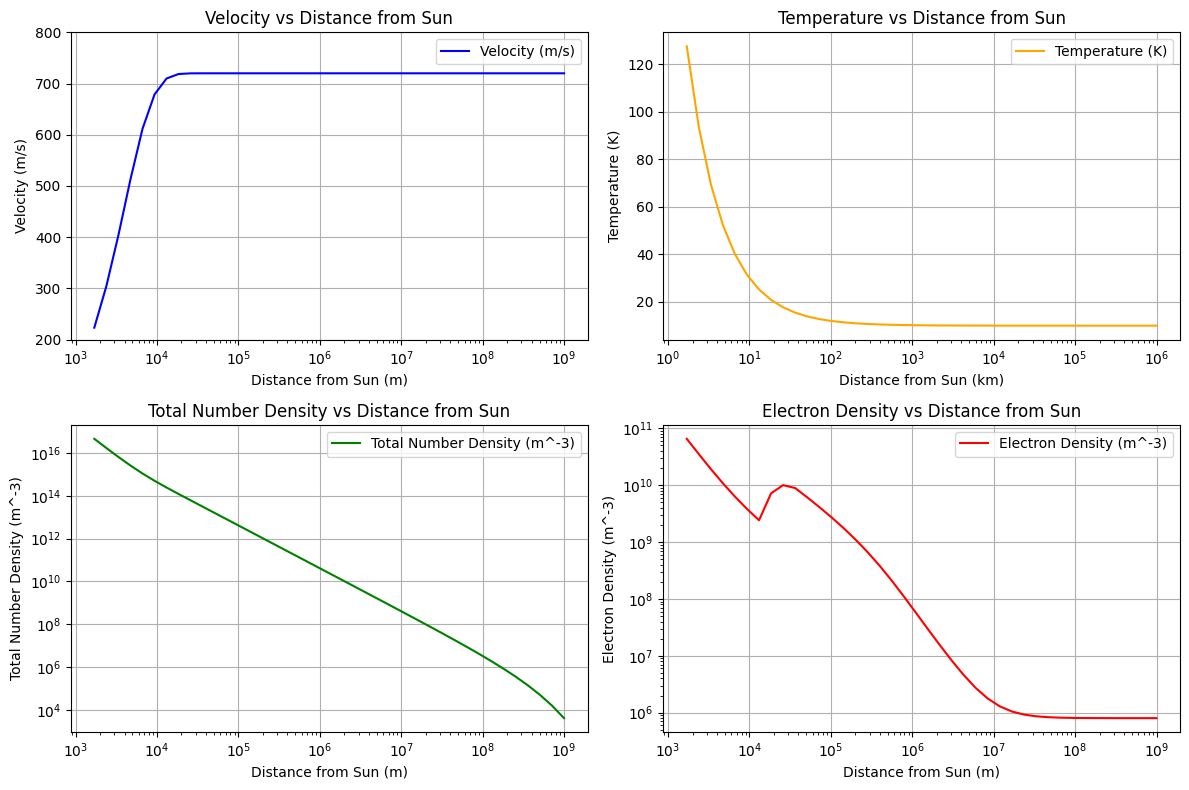

In [16]:
# Transition parameters
nu_Hz = 556.936e9
A_ul_s_1 = 3.456e-3
g_u = 9.0
g_l = 9.0
absorber_mass_kg = 18.01528 * constants.ATOMIC_MASS_UNIT

# Coma setup matching examples/coma.ipynb
heliocentric_distance_AU = 2.5
xc = np.logspace(np.log10(1.7e3), np.log10(1e9), 40)[::-1]
xf = np.empty(xc.size + 1, dtype=np.float64)
xf[1:-1] = np.sqrt(xc[:-1] * xc[1:])
xf[0] = xc[0] ** 2 / xf[1]
xf[-1] = xc[-1] ** 2 / xf[-2]
nlayer = xc.size

v0 = 720.0
c_scale = 5.3e3
velocity = velocity_tanh(xc, v0=v0, c=c_scale)
# velocity = np.interp(xc, rkm*1e3, velocity)

T0 = 10.0
temperature = temperature_inverse_distance(xc, a=10, b=1, t0=T0, r0=2000)

Q = 3.7e26
total_number_density = calc_density(
    Q,
    xc,
    velocity,
    r_h=heliocentric_distance_AU,
    model_type='isotropic',
    photo_dissociation=True,
)
nelec, telec = electron_biver_1997(
    Q,
    r_h=heliocentric_distance_AU,
    r=xc,
    v=velocity,
    t_kin=temperature,
    t_emax=10000,
)

# Initial level ratios: rL0 = 0.5, rL1 = 0.5
fractions = np.zeros((nlayer, 1), dtype=np.float64)
fractions[:, 0] = 0.0# level1_ratio
coma = ComaGrid(
    temperature=temperature,
    total_number_density=total_number_density,
    velocity=velocity,
    nelec=nelec,
    telec=telec,
    fractions=fractions,
)

coma.xf = xf
coma.xc = xc


# plot the profiles
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.semilogx(xc, velocity, label='Velocity (m/s)', color='blue')
plt.xlabel('Distance from Sun (m)')
plt.ylabel('Velocity (m/s)')
plt.ylim(200, 800)
plt.title('Velocity vs Distance from Sun')
plt.grid()
plt.legend()    
plt.subplot(2, 2, 2)
plt.semilogx(xc/1000, temperature, label='Temperature (K)', color='orange')
plt.xlabel('Distance from Sun (km)')
plt.ylabel('Temperature (K)')
plt.title('Temperature vs Distance from Sun')
plt.grid()
plt.legend()
plt.subplot(2, 2, 3)
plt.loglog(xc, total_number_density, label='Total Number Density (m^-3)', color='green')
plt.xlabel('Distance from Sun (m)')
plt.ylabel('Total Number Density (m^-3)')
plt.title('Total Number Density vs Distance from Sun')
plt.grid()
plt.legend()
plt.subplot(2, 2, 4)
plt.loglog(xc, nelec, label='Electron Density (m^-3)', color='red')
plt.xlabel('Distance from Sun (m)')
plt.ylabel('Electron Density (m^-3)')
plt.title('Electron Density vs Distance from Sun')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()






In [17]:
print(xc)

[1.00000000e+09 7.11316353e+08 5.05970953e+08 3.59905413e+08
 2.56006606e+08 1.82101685e+08 1.29531906e+08 9.21381632e+07
 6.55393821e+07 4.66192343e+07 3.31610237e+07 2.35879784e+07
 1.67785148e+07 1.19348319e+07 8.48944111e+06 6.03867828e+06
 4.29541061e+06 3.05539581e+06 2.17335300e+06 1.54594153e+06
 1.09965349e+06 7.82201510e+05 5.56392725e+05 3.95771244e+05
 2.81518558e+05 2.00248754e+05 1.42440213e+05 1.01320053e+05
 7.20706103e+04 5.12650037e+04 3.64656354e+04 2.59386028e+04
 1.84505523e+04 1.31241796e+04 9.33544355e+03 6.64045365e+03
 4.72346327e+03 3.35987667e+03 2.38993522e+03 1.70000000e+03]


Fitted sigma_0: 2.89e-18 m^2, beta: -1.00


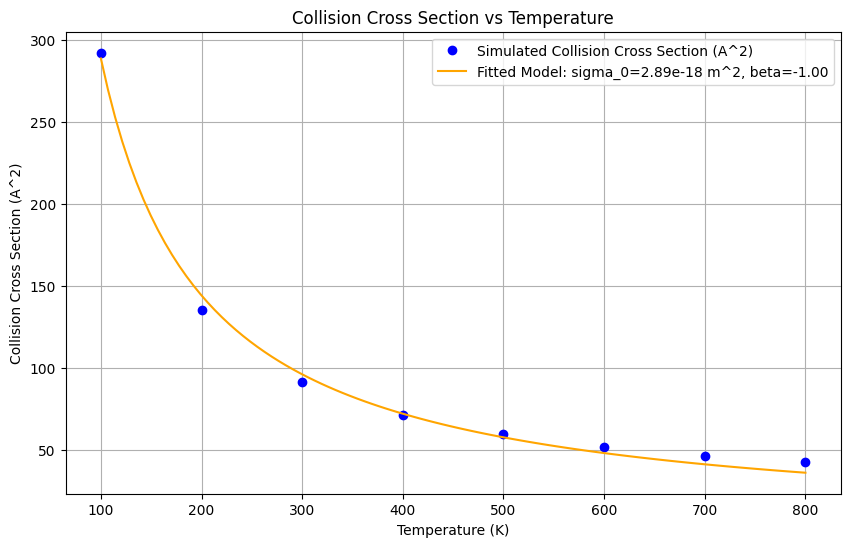

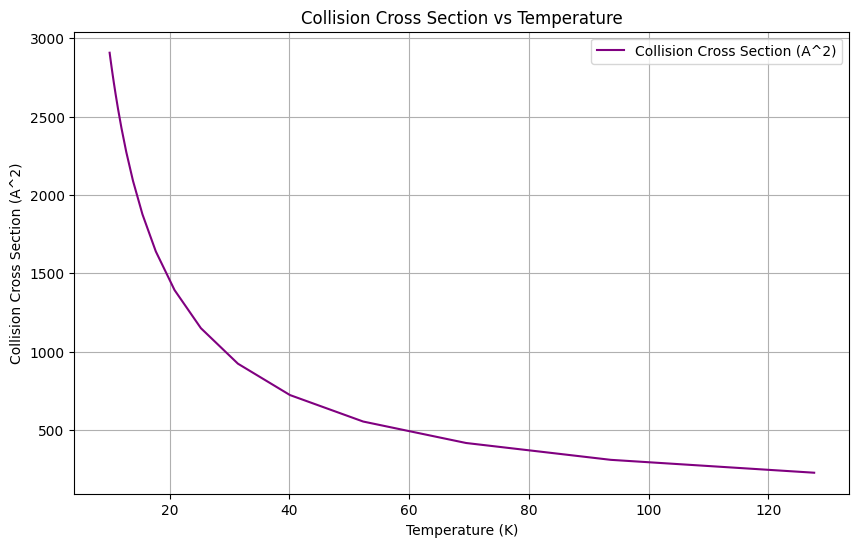

In [18]:
Ts= [100, 200, 300, 400, 500, 600, 700, 800]
simhs = np.array([292.4, 135.2, 91.6, 71.3, 59.5, 51.8, 46.4, 42.3]) * 1e-20

# use ww_sigma_ul_m2 to fit the data, to get alphe and beta
from scipy.optimize import curve_fit
def sigma_model(T, sigma_0, beta):
    return sigma_0 * (T / 100.) ** beta
popt, pcov = curve_fit(sigma_model, Ts, simhs)
sigma_0_fit, beta_fit = popt
print(f"Fitted sigma_0: {sigma_0_fit:.2e} m^2, beta: {beta_fit:.2f}")

# plot the data and the fit
plt.figure(figsize=(10, 6))
plt.plot(Ts, simhs*1e20, 'o', label='Simulated Collision Cross Section (A^2)', color='blue')
T_fit = np.linspace(min(Ts), max(Ts), 100)
sigma_fit = sigma_model(T_fit, *popt)
plt.plot(T_fit, sigma_fit*1e20, label=f'Fitted Model: sigma_0={sigma_0_fit:.2e} m^2, beta={beta_fit:.2f}', color='orange')
plt.xlabel('Temperature (K)')
plt.ylabel('Collision Cross Section (A^2)')
plt.title('Collision Cross Section vs Temperature')
plt.grid()
plt.legend()
plt.show()


simgas= sigma_model(temperature, *popt)
# to A2: 1e20
simgas_A2 = simgas * 1e20

# plot sigma vs temperature
plt.figure(figsize=(10, 6))
plt.plot(temperature, simgas_A2, label='Collision Cross Section (A^2)', color='purple')
plt.xlabel('Temperature (K)')
plt.ylabel('Collision Cross Section (A^2)')
plt.title('Collision Cross Section vs Temperature')
plt.grid()
plt.legend()
plt.show()

In [19]:


B_ul_SI, B_lu_SI = einstein_coeffs_B(
    nu_Hz=nu_Hz,
    A_ul_s_1=A_ul_s_1,
    g_u=g_u,
    g_l=g_l,
)
Cm_ul_s_1 = np.asarray(
    molecular_collision_rate(coma.total_number_density, coma.temperature, sigma_ul_m2=simgas),
    dtype=np.float64,
)
Cm_lu_s_1 = np.asarray(
    detailed_balance_excitation_rate(
        Cm_ul_s_1,
        coma.temperature,
        nu_Hz=nu_Hz,
        g_u=g_u,
        g_l=g_l,
    ),
    dtype=np.float64,
)
electron_rates = np.array(
    [
        electron_collision_rate(
            n_e=float(n_e),
            t_e=float(t_e),
            nu_Hz=nu_Hz,
            A_ul_s_1=A_ul_s_1,
            g_u=g_u,
            g_l=g_l,
        )
        for n_e, t_e in zip(coma.nelec, coma.telec)
    ],
    dtype=np.float64,
)
Ce_ul_s_1 = electron_rates[:, 0]
Ce_lu_s_1 = electron_rates[:, 1]
G_ul_s_1, G_lu_s_1 = scale_g_factors_from_1au(heliocentric_distance_AU)
G_ul_s_1 = np.full(nlayer, G_ul_s_1, dtype=np.float64)
G_lu_s_1 = np.full(nlayer, G_lu_s_1, dtype=np.float64)

print('Heliocentric distance (AU):', heliocentric_distance_AU)
print('Production rate Q (s^-1):', Q)
print('Initial lower-level density:', coma.density[:, 0])
print('Initial upper-level density:', coma.density[:, 1])


Heliocentric distance (AU): 2.5
Production rate Q (s^-1): 3.7e+26
Initial lower-level density: [4.03669896e+03 1.55672027e+04 4.94979377e+04 1.37198653e+05
 3.44912020e+05 8.08917016e+05 1.80569456e+06 3.89155422e+06
 8.17986455e+06 1.68906846e+07 3.44394087e+07 6.95916400e+07
 1.39726669e+08 2.79270259e+08 5.56370253e+08 1.10586696e+09
 2.19447373e+09 4.34962483e+09 8.61416578e+09 1.70497724e+10
 3.37319775e+10 6.67168382e+10 1.31927992e+11 2.60839219e+11
 5.15658525e+11 1.01933830e+12 2.01488792e+12 3.98259972e+12
 7.87173540e+12 1.55584321e+13 3.07507731e+13 6.07839414e+13
 1.20349522e+14 2.40790214e+14 4.97765243e+14 1.09218836e+15
 2.57427142e+15 6.45997382e+15 1.69389321e+16 4.56172776e+16]
Initial upper-level density: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


....temf... tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],
       dtype=torch.float64)
....intensity_levels... (1, 1, 1, 41, 16)
....temf... tensor([[  3.7869,   3.7869,   3.7870,   3.7870,   3.7870,   3.7871,   3.7872,
           3.7876,   3.7882,   3.7894,   3.7919,   3.7967,   3.8062,   3.8246,
           3.8598,   3.9246,   4.0388,   4.2272,   4.5168,   4.9345,   5.5090,
           6.2726,   7.2517,   8.4415,   9.7701,  11.0850,  12.2184,  13.1107,
          13.8675,  14.7009,  15.8485,  17.5282,  19.9519,  23.2481,  28.2206,
          35.6779,  46.1522,  60.8700,  81.5534, 110.6240, 127.6099]],
       dtype=torch.float64)
....intensity_levels... (1, 1, 1, 41, 16)
....temf... tensor([[  4.0942,   4.0944,   4.0948,   4.0957,   4.0975,   4.1005,   4.1054,
           4.1128,   4.1233,   4.1377,   4.1567,   4.1815,   4.2143,   4.2592,
           4.324

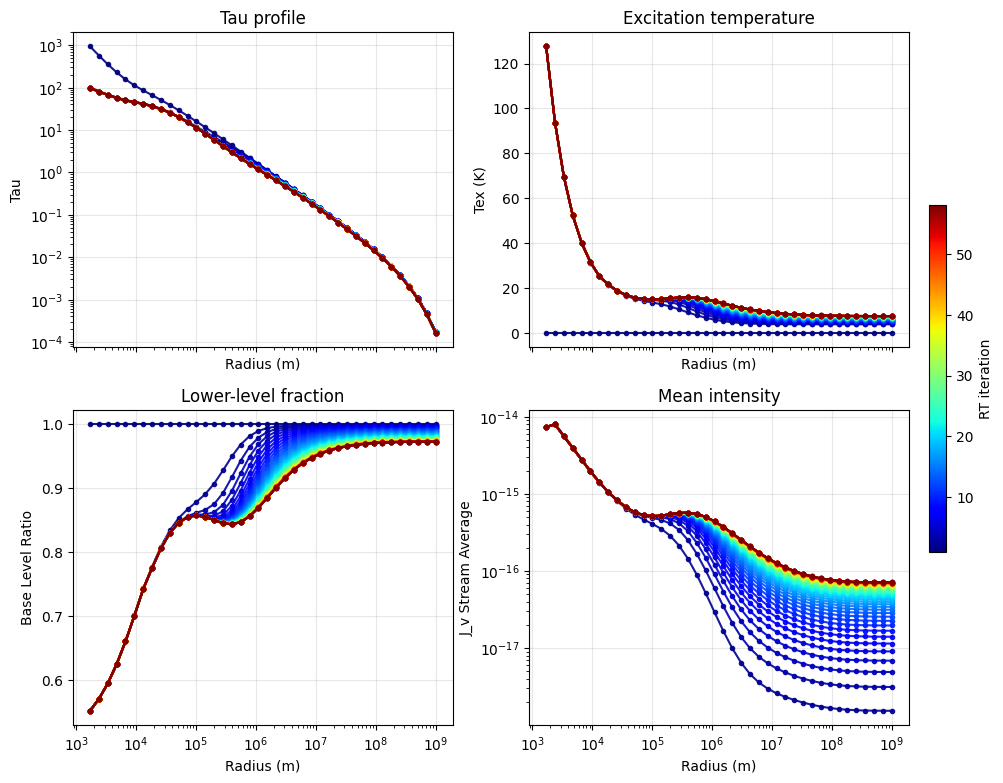

Final J_v_stream_average: [7.09959159e-17 7.10592297e-17 7.12102881e-17 7.15203560e-17
 7.20898756e-17 7.30526901e-17 7.45807167e-17 7.68882089e-17
 8.02347135e-17 8.49284123e-17 9.13381561e-17 9.99308075e-17
 1.11348354e-16 1.26509683e-16 1.46677129e-16 1.73424719e-16
 2.08479958e-16 2.53363780e-16 3.08647134e-16 3.72739241e-16
 4.40551445e-16 5.03007328e-16 5.48830352e-16 5.69386547e-16
 5.64463163e-16 5.43818570e-16 5.22261190e-16 5.13431212e-16
 5.28079086e-16 5.76346949e-16 6.70222774e-16 8.25102083e-16
 1.05685325e-15 1.40947041e-15 1.95957466e-15 2.77478825e-15
 3.94166593e-15 5.60099670e-15 7.94679336e-15 7.39125884e-15]
Final relative change: [9.53472434e-04 9.53457889e-04 9.53423197e-04 9.53352035e-04
 9.53221442e-04 9.53000646e-04 9.52648540e-04 9.52106958e-04
 9.51282427e-04 9.50001385e-04 9.47916624e-04 9.44348512e-04
 9.38077827e-04 9.27144989e-04 9.08678349e-04 8.78728876e-04
 8.32330508e-04 7.64399179e-04 6.71825264e-04 5.56126560e-04
 4.25228201e-04 2.93014527e-04 1.76

In [20]:
max_rt_iterations = 2000
jv_rtol = 1.0e-3
jv_floor = 1.0e-30
population_tolerance = 1.0e-10
packet_fraction_range = (0.05, 0.35)
random_seed = 7

history = []
previous_jv = None
converged = False


for iteration in range(1, max_rt_iterations + 1):
    disort_result = solve_disort_layers(
        coma,
        lower_level=0,
        upper_level=1,
        nu_Hz=nu_Hz,
        A_ul_s_1=A_ul_s_1,
        g_u=g_u,
        g_l=g_l,
        absorber_mass_kg=absorber_mass_kg,
        nstreams=16,
    )
    jv_average_stream = np.asarray(disort_result['J_v_stream_average'], dtype=np.float64)

    tau_profile = np.asarray(disort_result['tau_profile'], dtype=np.float64)
    excitation_temperature = np.asarray(disort_result['excitation_temperature_K'], dtype=np.float64)
    base_level_ratio = coma.density[:, 0] / np.maximum(coma.density[:, 0] + coma.density[:, 1], 1.0e-300)

    if previous_jv is None:
        relative_change = np.full_like(jv_average_stream, np.inf)
    else:
        scale = np.maximum(np.abs(previous_jv), jv_floor)
        relative_change = np.abs(jv_average_stream - previous_jv) / scale
        if np.all(relative_change <= jv_rtol):
            history.append({
                'iteration': iteration,
                'J_v_stream_average': jv_average_stream.copy(),
                # 'J_v_quadrature': np.asarray(disort_result['J_v'], dtype=np.float64).copy(),
                'relative_change': relative_change.copy(),
                'tau_profile': tau_profile.copy(),
                'excitation_temperature_K': excitation_temperature.copy(),
                'base_level_ratio': base_level_ratio.copy(),
                'n_lower': coma.density[:, 0].copy(),
                'n_upper': coma.density[:, 1].copy(),
                'population_iterations_used': 0,
            })
            converged = True
            print(f'Converged at RT iteration {iteration}.')
            break

    pop_result = monte_carlo_two_level_populations(
        coma,
        jv_average_stream,
        A_ul_s_1=A_ul_s_1,
        B_ul_SI=B_ul_SI,
        B_lu_SI=B_lu_SI,
        Cm_ul_s_1=Cm_ul_s_1,
        Cm_lu_s_1=Cm_lu_s_1,
        Ce_ul_s_1=Ce_ul_s_1,
        Ce_lu_s_1=Ce_lu_s_1,
        G_ul_s_1=G_ul_s_1,
        G_lu_s_1=G_lu_s_1,
        nu_Hz=nu_Hz,
        g_u=g_u,
        g_l=g_l,
        lower_level=0,
        upper_level=1,
        max_iterations=20000,
        tolerance=population_tolerance,
        packet_fraction_range=packet_fraction_range,
        random_seed=random_seed + iteration - 1,
    )

    history.append({
        'iteration': iteration,
        'J_v_stream_average': jv_average_stream.copy(),
        # 'J_v_quadrature': np.asarray(disort_result['J_v'], dtype=np.float64).copy(),
        'relative_change': relative_change.copy(),
        'tau_profile': tau_profile.copy(),
        'excitation_temperature_K': excitation_temperature.copy(),
        'base_level_ratio': base_level_ratio.copy(),
        'n_lower': np.asarray(pop_result['n_lower'], dtype=np.float64).copy(),
        'n_upper': np.asarray(pop_result['n_upper'], dtype=np.float64).copy(),
        'population_iterations_used': int(pop_result['iterations_used']),
    })

    previous_jv = jv_average_stream

if not converged:
    print(f'No J_v convergence after {max_rt_iterations} RT iterations.')

if history:
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
    ax0, ax1, ax2, ax3 = axes.flatten()

    iterations = np.array([item['iteration'] for item in history], dtype=int)
    norm = mpl.colors.Normalize(vmin=iterations.min(), vmax=iterations.max())
    cmap = plt.cm.jet

    for item in history:
        color = cmap(norm(item['iteration']))
        label = f"Iter {item['iteration']}"
        ax0.loglog(coma.xc, item['tau_profile'], color=color, marker='.', linewidth=1.5, alpha=0.9)
        ax1.semilogx(coma.xc, item['excitation_temperature_K'], color=color, marker='.', linewidth=1.5, alpha=0.9)
        ax2.semilogx(coma.xc, item['base_level_ratio'], color=color, marker='.', linewidth=1.5, alpha=0.9)
        if item['iteration'] == 1: continue
        ax3.loglog(coma.xc, np.maximum(item['J_v_stream_average'], jv_floor), color=color, marker='.', linewidth=1.5, alpha=0.9, label=label)

    for ax in (ax0, ax1, ax2, ax3):
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('Radius (m)')

    ax0.set_ylabel('Tau')
    ax0.set_title('Tau profile')
    ax1.set_ylabel('Tex (K)')
    ax1.set_title('Excitation temperature')
    ax2.set_ylabel('Base Level Ratio')
    ax2.set_title('Lower-level fraction')
    ax3.set_ylabel('J_v Stream Average')
    ax3.set_title('Mean intensity')

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, pad=0.02, shrink=0.5)
    cbar.set_label('RT iteration')
    # cbar.set_position([0, 1])

    # plt.tight_layout()
    plt.show()

final_state = history[-1]
print('Final J_v_stream_average:', final_state['J_v_stream_average'])
print('Final relative change:', final_state['relative_change'])
print('Final n1/n0:', final_state['n_upper'] / np.maximum(final_state['n_lower'], 1.0e-300))




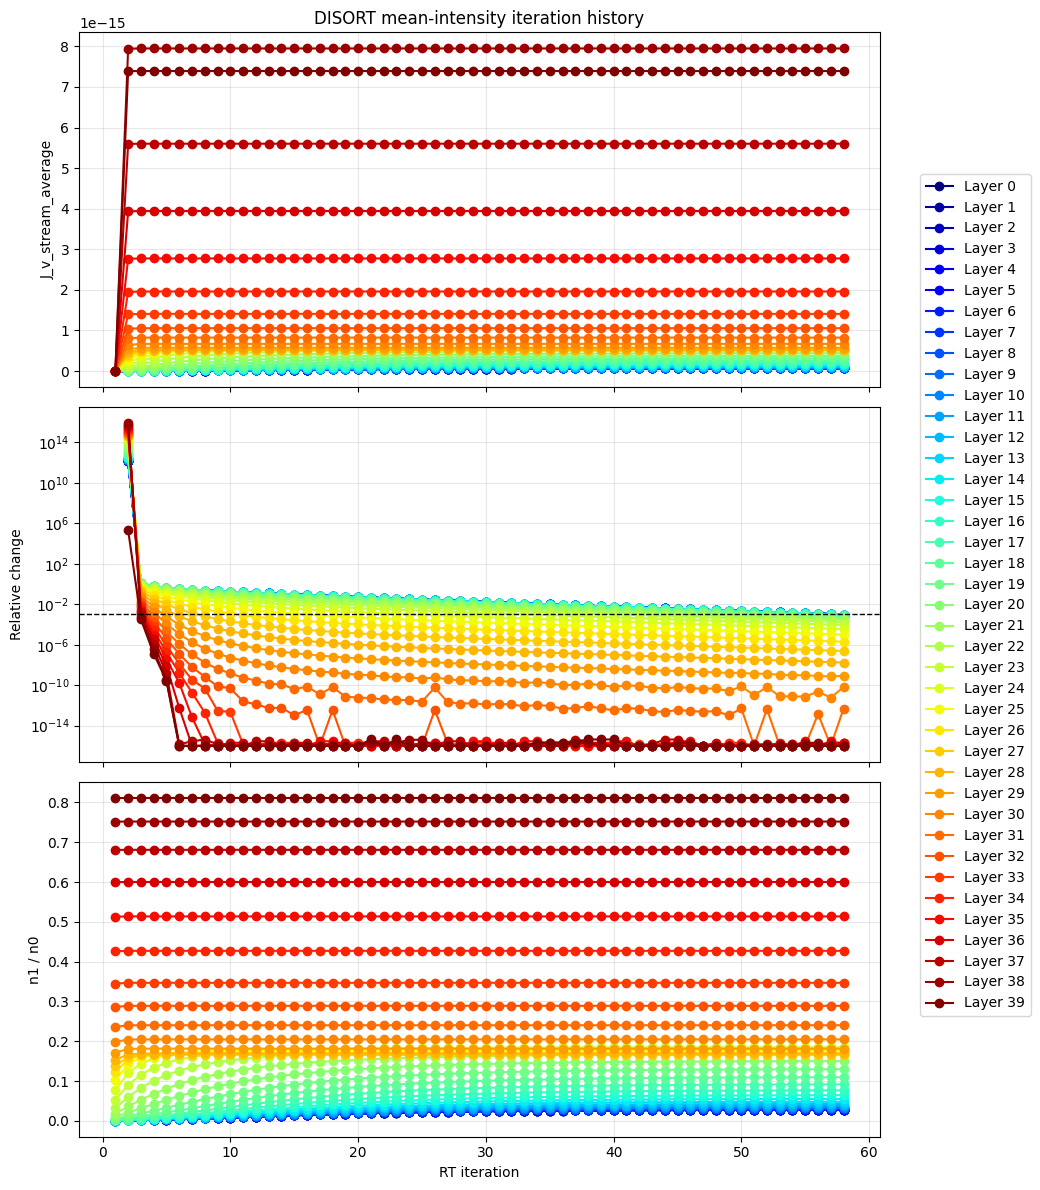

In [21]:
iterations = np.array([item['iteration'] for item in history], dtype=int)
jv_history = np.vstack([item['J_v_stream_average'] for item in history])
rel_history = np.vstack([item['relative_change'] for item in history])
ratio_history = np.vstack([
    item['n_upper'] / np.maximum(item['n_lower'], 1.0e-300)
    for item in history
])

fig, axes = plt.subplots(3, 1, figsize=(9, 12), sharex=True)


norm = mpl.colors.Normalize(vmin=0, vmax=nlayer-1)
cmap = plt.cm.jet



for layer in range(nlayer):
    color = cmap(norm(layer))
    axes[0].plot(iterations, jv_history[:, layer], marker='o', label=f'Layer {layer}', color=color)
axes[0].set_ylabel('J_v_stream_average')
axes[0].set_title('DISORT mean-intensity iteration history')
axes[0].grid(True, alpha=0.3)

for layer in range(nlayer):
    color = cmap(norm(layer))
    axes[1].semilogy(iterations, np.maximum(rel_history[:, layer], 1.0e-16), marker='o', label=f'Layer {layer}', color=color)
axes[1].axhline(1.0e-3, color='k', linestyle='--', linewidth=1.0, label='Convergence threshold')
axes[1].set_ylabel('Relative change')
axes[1].grid(True, alpha=0.3)

for layer in range(nlayer):
    color = cmap(norm(layer))
    axes[2].plot(iterations, np.maximum(ratio_history[:, layer], 1.0e-30), marker='o', label=f'Layer {layer}', color=color)
axes[2].set_xlabel('RT iteration')
axes[2].set_ylabel('n1 / n0')
axes[2].grid(True, alpha=0.3)

handles, labels = axes[2].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5))
fig.tight_layout()
plt.show()


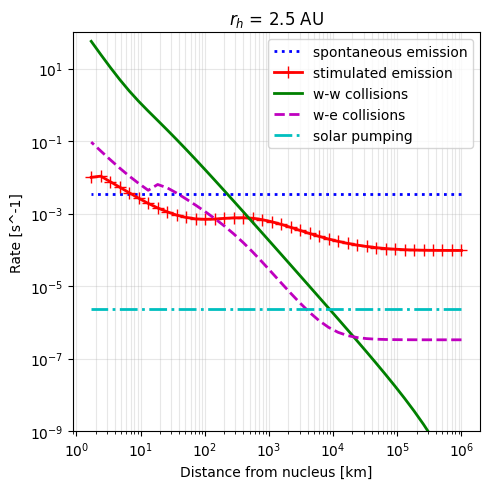

In [22]:
r_km = coma.xc * 1.0e-3
J_nu = np.asarray(final_state['J_v_stream_average'], dtype=np.float64)

A_profile = np.broadcast_to(np.asarray(A_ul_s_1, dtype=np.float64), r_km.shape)
stimulated_profile = np.broadcast_to(np.asarray(B_ul_SI, dtype=np.float64), r_km.shape) * J_nu
Cm_profile = np.broadcast_to(np.asarray(Cm_ul_s_1, dtype=np.float64), r_km.shape)
Ce_profile = np.broadcast_to(np.asarray(Ce_ul_s_1, dtype=np.float64), r_km.shape)
G_profile = np.broadcast_to(np.asarray(G_ul_s_1, dtype=np.float64), r_km.shape)

fig, ax = plt.subplots(figsize=(5, 5))
ax.loglog(r_km, A_profile, 'b:', lw=2, label=r'spontaneous emission')
ax.loglog(r_km, stimulated_profile, 'r+-', lw=2, markersize=8, label=r'stimulated emission')
ax.loglog(r_km, Cm_profile, 'g-', lw=2, label=r'w-w collisions')
ax.loglog(r_km, Ce_profile, 'm--', lw=2, label=r'w-e collisions')
ax.loglog(r_km, G_profile, 'c-.', lw=2, label=r'solar pumping')
ax.set_ylim(1.0e-9, 1.0e2)
ax.set_xlabel('Distance from nucleus [km]')
ax.set_ylabel('Rate [s^-1]')
ax.set_title(r'$r_h$ = 2.5 AU')
ax.grid(True, which='both', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()
